In [ ]:
from typing import TypedDict, Literal

class ParentClass(TypedDict):
    usd_amount : float
    total_usd_amount : float
    target_currency : Literal['BDT', 'EUR']     # Literal restrict values to exact constants
    total_amount : float

In [19]:
def convert_total_usd(state: ParentClass) -> ParentClass:
    state['total_usd_amount'] = state['usd_amount'] *  1.12
    
    return state

In [20]:
def convert_usd_to_bdt(state: ParentClass) -> ParentClass:
    state['total_amount'] = state['usd_amount'] * 122

    return state

In [21]:
def convert_usd_to_eur(state: ParentClass) -> ParentClass:
    state['total_amount'] = state['usd_amount'] * 0.8
    
    return state

In [22]:
def choose_currency(state: ParentClass) -> str:
    return state['target_currency']

#### **Create Nodes and Edges**

In [23]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(ParentClass)

graph.add_node('Total USD amount', convert_total_usd)
graph.add_node('Convert USD to BDT amount', convert_usd_to_bdt)
graph.add_node('Convert USD to EUR amount', convert_usd_to_eur)

graph.add_edge(START, 'Total USD amount')
graph.add_conditional_edges(
    'Total USD amount',
    choose_currency,
    {
        "BDT": 'Convert USD to BDT amount',
        "EUR" : 'Convert USD to EUR amount'
    }
)
graph.add_edge(['Convert USD to BDT amount', 'Convert USD to EUR amount'], END)

graph = graph.compile()

#### **Draw the image**

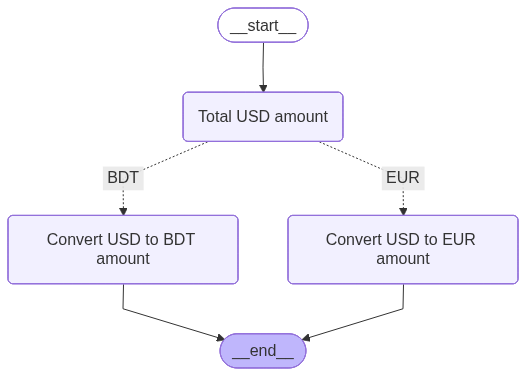

In [24]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

#### **Test it out**

In [25]:
graph.invoke({'usd_amount': 1000, 'target_currency':'BDT'})

{'usd_amount': 1000,
 'total_usd_amount': 1120.0,
 'target_currency': 'BDT',
 'total_amount': 122000}